# Descripcipción del proyecto

Film Junky Union, una nueva comunidad vanguardista para los aficionados de las películas clásicas, está desarrollando un sistema para filtrar y categorizar reseñas de películas. Tu objetivo es entrenar un modelo para detectar las críticas negativas de forma automática. Para lograrlo, utilizarás un conjunto de datos de reseñas de películas de IMDB con leyendas de polaridad para construir un modelo para clasificar las reseñas positivas y negativas. Este deberá alcanzar un valor F1 de al menos 0.85.

## Inicialización

In [1]:

import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# la siguiente línea proporciona gráficos de mejor calidad en pantallas HiDPI
# %config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# esto es para usar progress_apply, puedes leer más en https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Cargar datos

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
print(f"Dimensiones del dataset: {df_reviews.shape}")
display(df_reviews.head())
display(df_reviews.info())

Dimensiones del dataset: (47331, 17)


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

None

In [6]:
print("\nValores ausentes por columna:")
print(df_reviews.isnull().sum())


Valores ausentes por columna:
tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64


## EDA

Veamos el número de películas y reseñas a lo largo de los años.

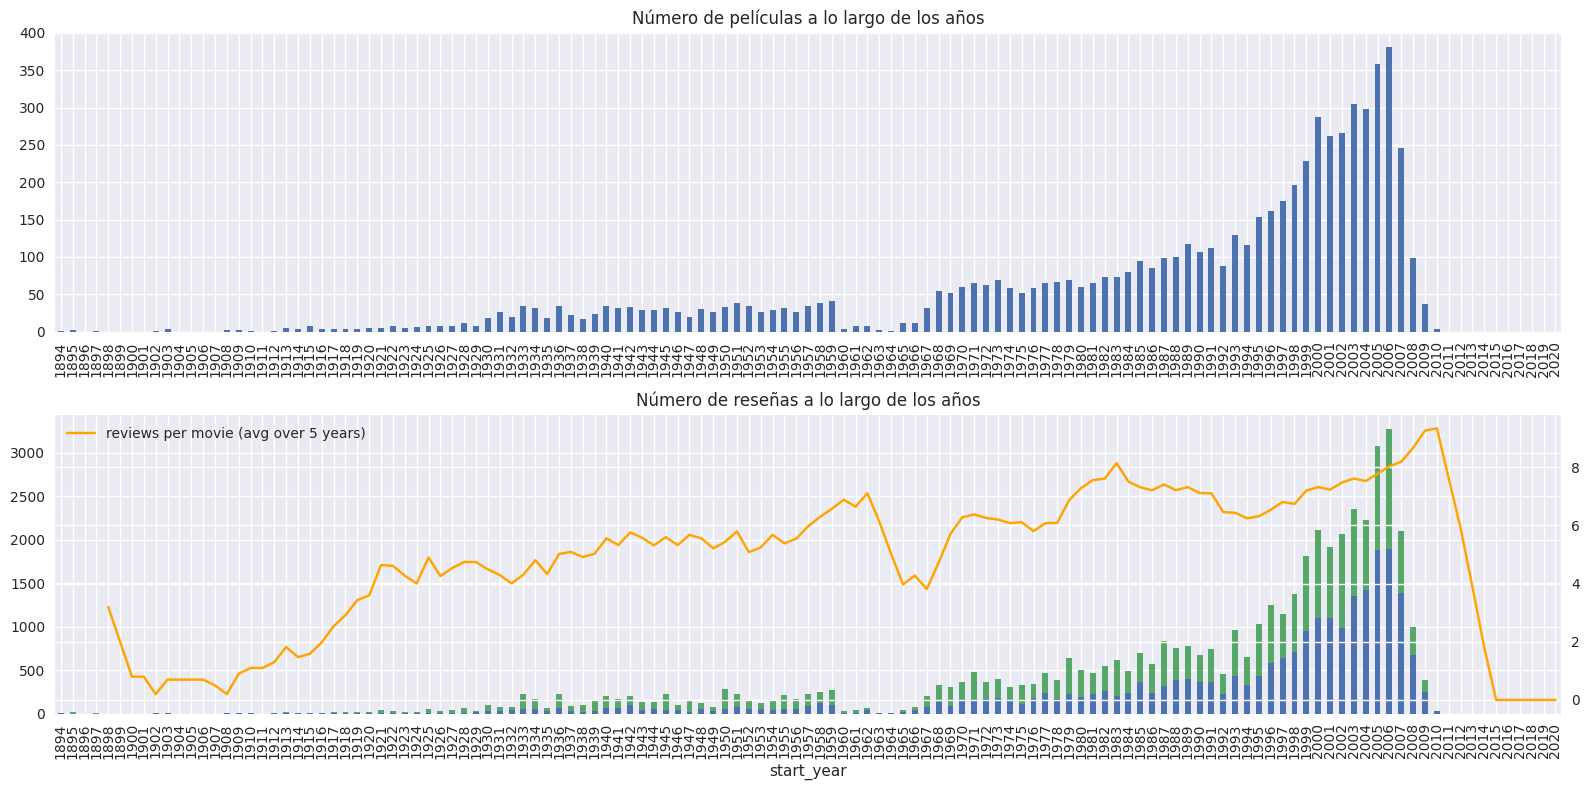

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de reseñas a lo largo de los años')

fig.tight_layout()

Veamos la distribución del número de reseñas por película con el conteo exacto y KDE (solo para saber cómo puede diferir del conteo exacto)

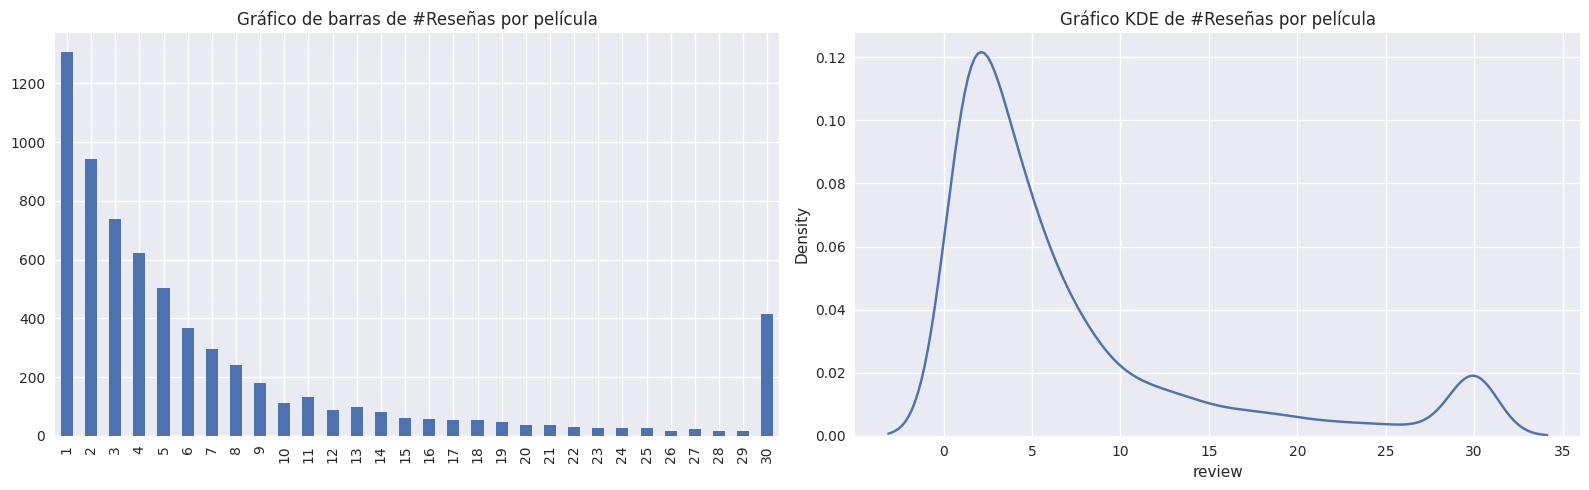

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de barras de #Reseñas por película')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico KDE de #Reseñas por película')

fig.tight_layout()

In [9]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

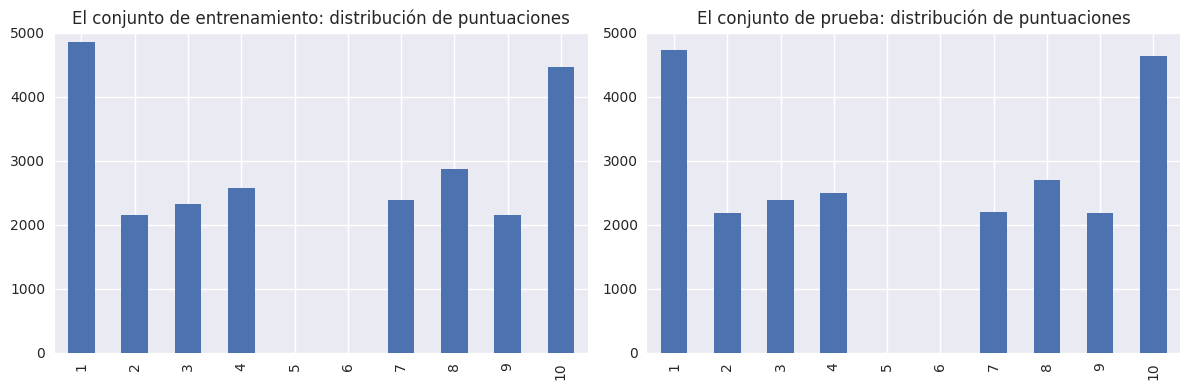

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()

Distribución de reseñas negativas y positivas a lo largo de los años para dos partes del conjunto de datos

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


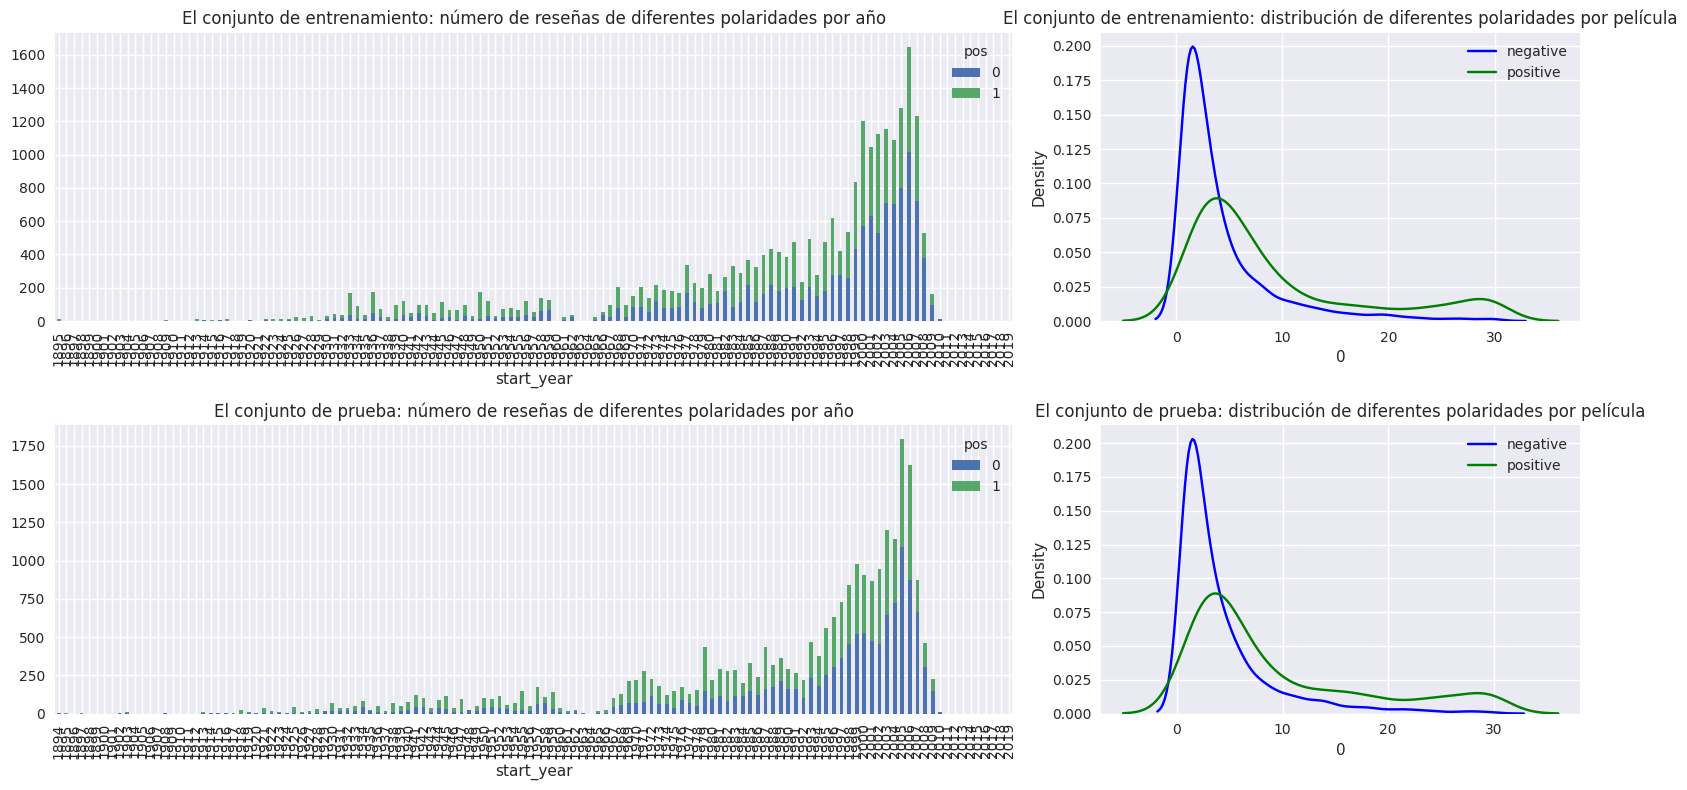

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de entrenamiento: número de reseñas de diferentes polaridades por año')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de entrenamiento: distribución de diferentes polaridades por película')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('El conjunto de prueba: número de reseñas de diferentes polaridades por año')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('El conjunto de prueba: distribución de diferentes polaridades por película')

fig.tight_layout()

## Procedimiento de evaluación

Composición de una rutina de evaluación que se pueda usar para todos los modelos en este proyecto

In [12]:
import sklearn.metrics as metrics
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return

## Normalización

Suponemos que todos los modelos a continuación aceptan textos en minúsculas y sin dígitos, signos de puntuación, etc.

In [13]:
import re

def clear_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]*>', ' ', text)
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = " ".join(text.split())
    return text

df_reviews['review_norm'] = df_reviews['review'].progress_apply(clear_text)

print("Reseña original:")
print(df_reviews['review'].iloc[0][:200])
print("\nReseña normalizada:")
print(df_reviews['review_norm'].iloc[0][:200])

  0%|          | 0/47331 [00:00<?, ?it/s]

Reseña original:
The pakage implies that Warren Beatty and Goldie Hawn are pulling off a huge bank robbery, but that's not what I got out of it! I didn't get anything! In the first half there's a new character (withou

Reseña normalizada:
the pakage implies that warren beatty and goldie hawn are pulling off a huge bank robbery but that s not what i got out of it i didn t get anything in the first half there s a new character without in


## División entrenamiento / prueba

Por fortuna, todo el conjunto de datos ya está dividido en partes de entrenamiento/prueba; 'ds_part' es el indicador correspondiente.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabajar con modelos

### Modelo 0 - Constante

In [15]:
from sklearn.dummy import DummyClassifier

In [16]:
model_0 = DummyClassifier(strategy='stratified', random_state=42)

In [17]:
model_0.fit(df_reviews_train['review_norm'], train_target)

DummyClassifier(random_state=42, strategy='stratified')

Evaluación Modelo 0 (Constante):
          train  test
Accuracy    0.5   0.5
F1          0.5   0.5
APS         0.5   0.5
ROC AUC     0.5   0.5


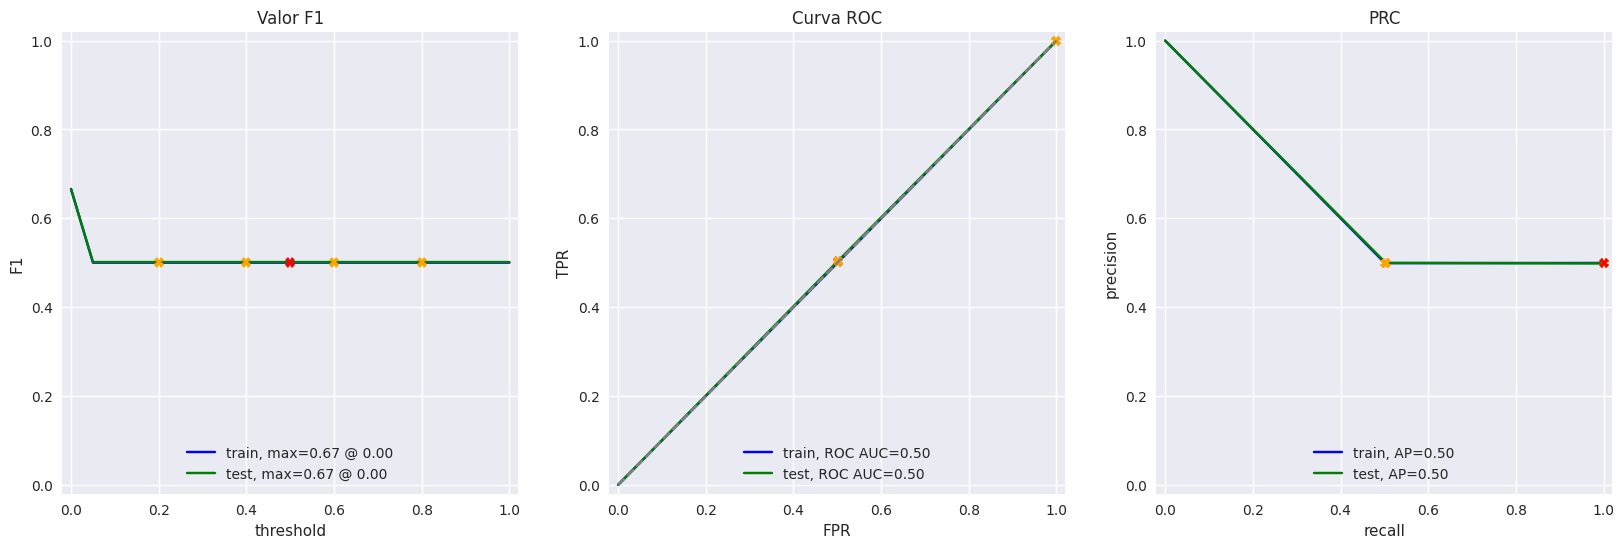

In [18]:
print("Evaluación Modelo 0 (Constante):")
evaluate_model(model_0, 
               df_reviews_train['review_norm'], train_target, 
               df_reviews_test['review_norm'], test_target)

### Modelo 1 - NLTK, TF-IDF y LR

TF-IDF

In [19]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords 
nltk.download('stopwords')
stop_words = list(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:
count_tf_idf = TfidfVectorizer(stop_words=stop_words)

In [21]:
print("Vectorizando textos...")
train_features_1 = count_tf_idf.fit_transform(df_reviews_train['review_norm'])
test_features_1 = count_tf_idf.transform(df_reviews_test['review_norm'])

print("Entrenando Regresión Logística...")
model_1 = LogisticRegression(random_state=42, solver='liblinear')
model_1.fit(train_features_1, train_target)

print("Evaluación Modelo 1 (TF-IDF + LR):")

Vectorizando textos...
Entrenando Regresión Logística...
Evaluación Modelo 1 (TF-IDF + LR):


          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


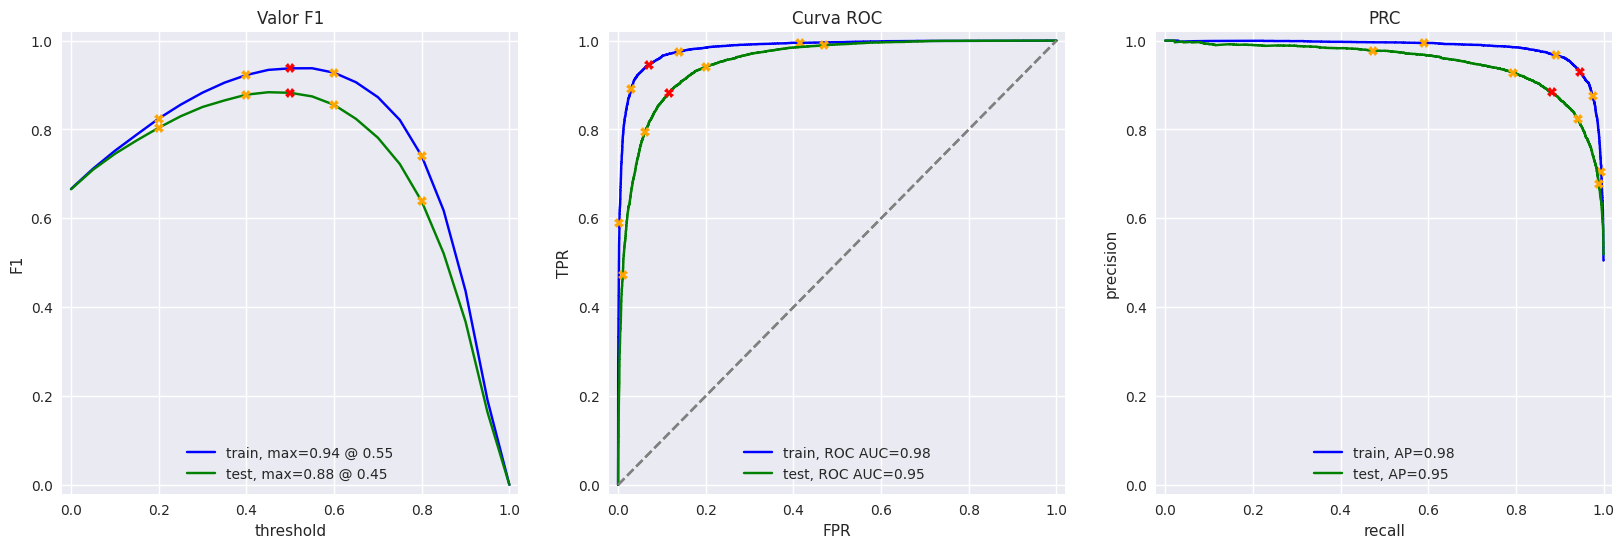

In [22]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

### Modelo 3 - spaCy, TF-IDF y LR

In [23]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [24]:
def text_preprocessing_3(text):

    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]

    return ' '.join(tokens)

In [25]:
print("Lematizando textos con spaCy (esto puede tardar unos minutos)...")

Lematizando textos con spaCy (esto puede tardar unos minutos)...


In [26]:
df_reviews_train['review_spacy'] = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/23796 [00:00<?, ?it/s]

In [27]:
df_reviews_test['review_spacy'] = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/23535 [00:00<?, ?it/s]

Vectorizando textos lematizados...
Entrenando Regresión Logística (Modelo 3)...
Evaluación Modelo 3 (spaCy + TF-IDF + LR):
          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


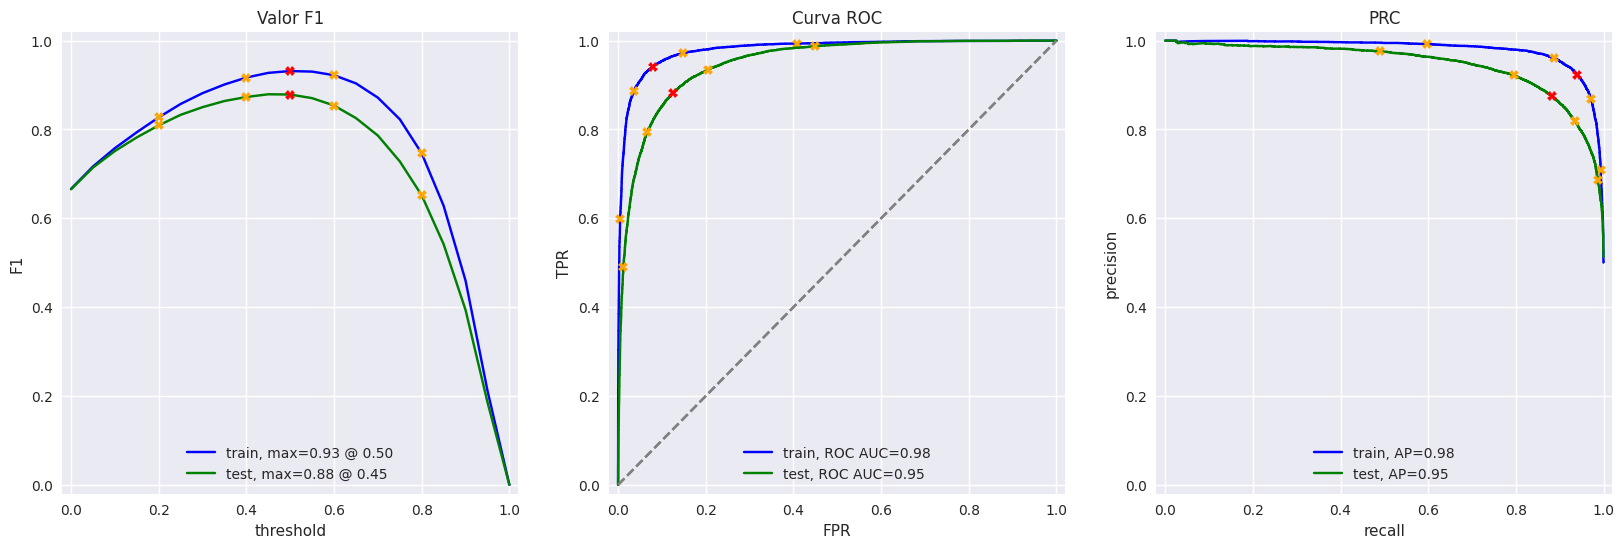

In [28]:
count_tf_idf_3 = TfidfVectorizer(stop_words=stop_words)
print("Vectorizando textos lematizados...")
train_features_3 = count_tf_idf_3.fit_transform(df_reviews_train['review_spacy'])
test_features_3 = count_tf_idf_3.transform(df_reviews_test['review_spacy'])

print("Entrenando Regresión Logística (Modelo 3)...")
model_3 = LogisticRegression(random_state=42, solver='liblinear')
model_3.fit(train_features_3, train_target)

print("Evaluación Modelo 3 (spaCy + TF-IDF + LR):")
evaluate_model(model_3, 
               train_features_3, train_target, 
               test_features_3, test_target)

### Modelo 4 - spaCy, TF-IDF y LGBMClassifier

In [29]:
from lightgbm import LGBMClassifier

In [30]:
print("Entrenando LightGBM (Modelo 4)...")

Entrenando LightGBM (Modelo 4)...


In [31]:
model_4 = LGBMClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    random_state=42,
    n_jobs=-1 
)


model_4.fit(train_features_3, train_target)

LGBMClassifier(n_estimators=200, random_state=42)

Evaluación Modelo 4 (spaCy + TF-IDF + LGBM):
          train  test
Accuracy   0.96  0.87
F1         0.96  0.87
APS        0.99  0.94
ROC AUC    0.99  0.94


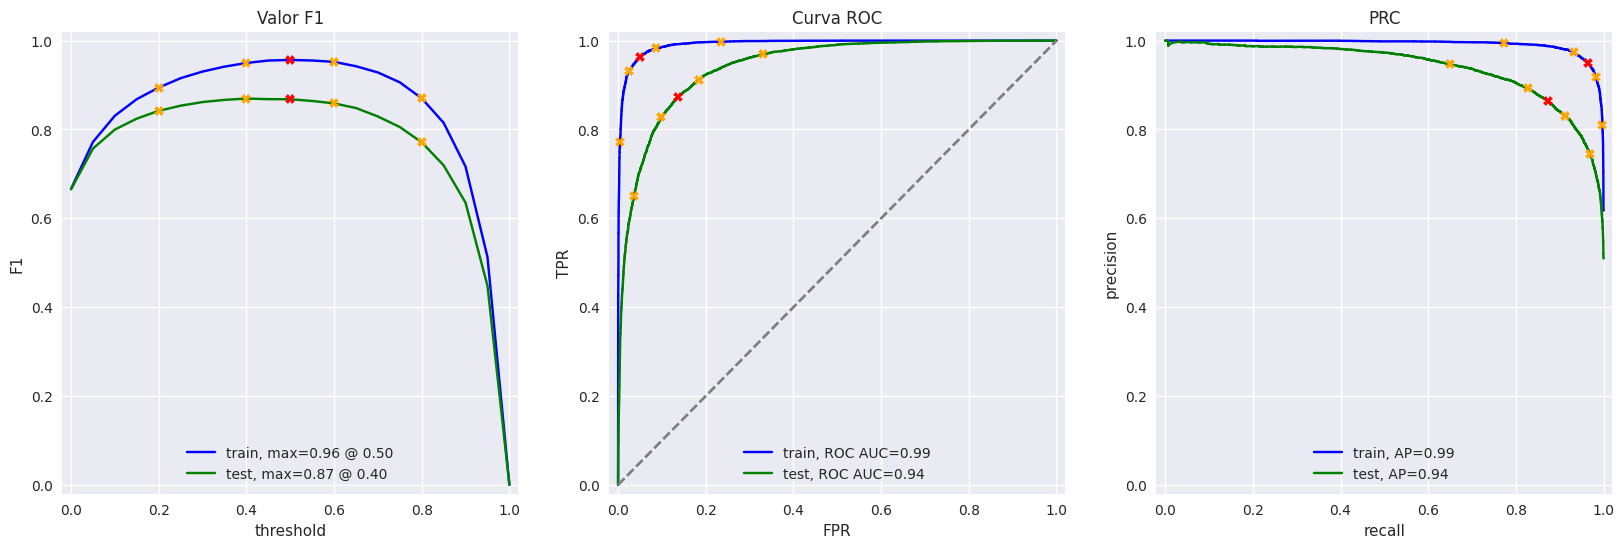

In [32]:
print("Evaluación Modelo 4 (spaCy + TF-IDF + LGBM):")
evaluate_model(model_4, 
               train_features_3, train_target, 
               test_features_3, test_target)

###  Modelo 9 - BERT

In [33]:
import torch
import transformers

In [34]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [35]:
sample_size = 300 

df_train_sample = df_reviews_train.sample(sample_size, random_state=42)
df_test_sample = df_reviews_test.sample(sample_size, random_state=42)

def BERT_text_to_embeddings(texts, max_length=128, batch_size=20, force_device=None, disable_progress_bar=False):

    ids_list = []
    attention_mask_list = []

    for text in tqdm(texts, disable=disable_progress_bar, desc="Tokenizando"):
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True)
        
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])

    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    if not disable_progress_bar:
        print(f'Uso del dispositivo {device}.')

    # obtener insertados en lotes

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):

        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)

        with torch.no_grad():
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())

    return np.concatenate(embeddings)

In [36]:
print(f"Generando embeddings ligeros para {sample_size} ejemplos...")
train_features_9 = BERT_text_to_embeddings(df_train_sample['review_norm'])
test_features_9 = BERT_text_to_embeddings(df_test_sample['review_norm'])


Generando embeddings ligeros para 300 ejemplos...


Tokenizando:   0%|          | 0/300 [00:00<?, ?it/s]

Uso del dispositivo cpu.


  0%|          | 0/15 [00:00<?, ?it/s]

Tokenizando:   0%|          | 0/300 [00:00<?, ?it/s]

Uso del dispositivo cpu.


  0%|          | 0/15 [00:00<?, ?it/s]

In [37]:
model_9 = LogisticRegression(random_state=42, solver='liblinear')
model_9.fit(train_features_9, df_train_sample['pos'])

LogisticRegression(random_state=42, solver='liblinear')

Evaluación Modelo 9 (BERT ligero):
          train  test
Accuracy    1.0  0.74
F1          1.0  0.73
APS         1.0  0.82
ROC AUC     1.0  0.82


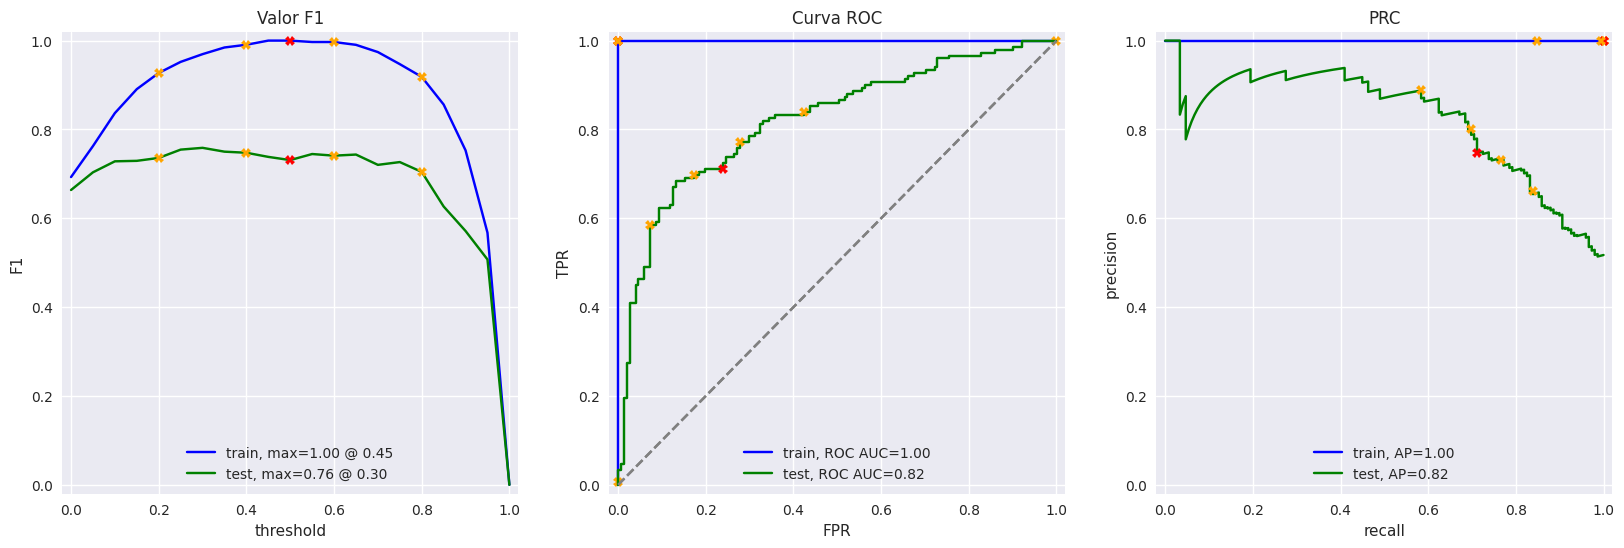

In [38]:
print("Evaluación Modelo 9 (BERT ligero):")
evaluate_model(model_9, train_features_9, df_train_sample['pos'], test_features_9, df_test_sample['pos'])

Evaluación Modelo 9 (BERT + LR):
          train  test
Accuracy    1.0  0.74
F1          1.0  0.73
APS         1.0  0.82
ROC AUC     1.0  0.82


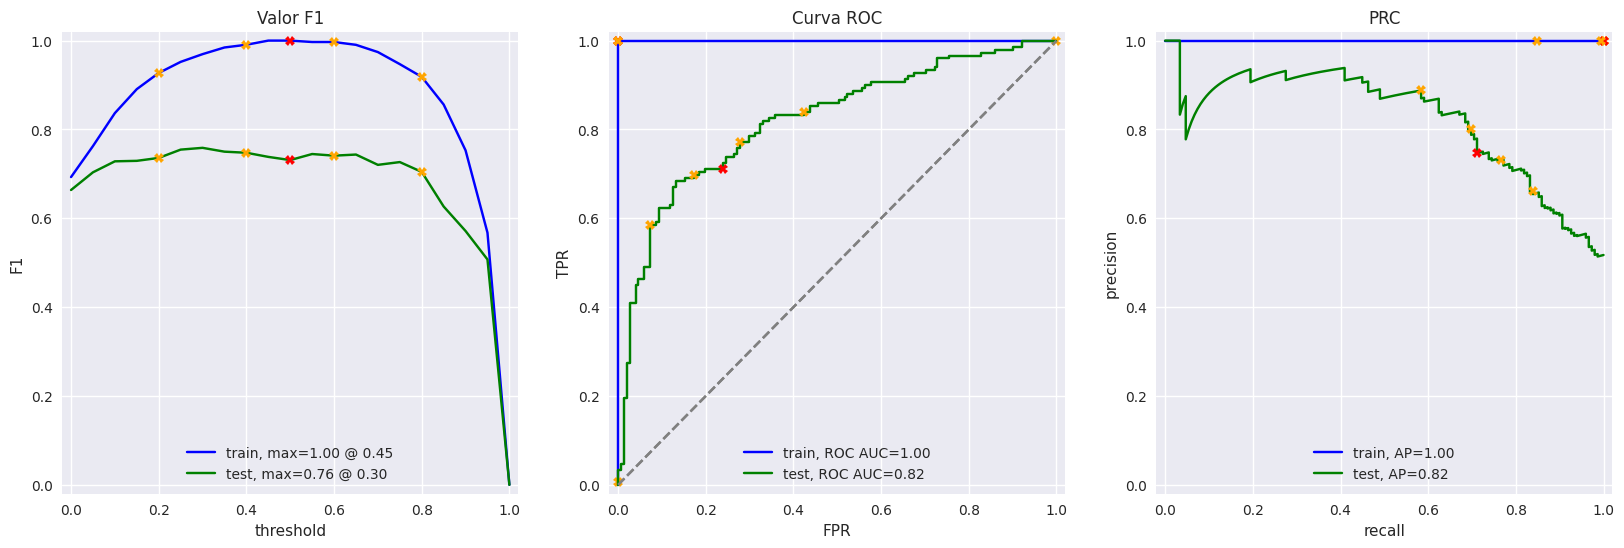

In [39]:
print("Evaluación Modelo 9 (BERT + LR):")
evaluate_model(model_9, 
               train_features_9, df_train_sample['pos'], 
               test_features_9, df_test_sample['pos'])

In [40]:
# si ya obtuviste los insertados, te recomendamos guardarlos para tenerlos listos si
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# y cargar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## Mis reseñas

In [41]:
my_reviews = pd.DataFrame([
    'I did not like this movie at all. The acting was terrible and the plot was boring.', # Muy negativa
    'What a masterpiece! The cinematography and the soundtrack were absolutely stunning.', # Muy positiva
    'It was okay, I guess. Not the best I have seen, but definitely not the worst.', # Neutra/Ambigua
    'I fell asleep halfway through. Total waste of time and money.', # Muy negativa
    'An emotional rollercoaster that kept me on the edge of my seat until the very end. Brilliant!', # Muy positiva
    'The plot was predictable and the characters were shallow. I expected much more.' # Negativa/Decepcionada
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].progress_apply(clear_text)
my_reviews['review_spacy'] = my_reviews['review_norm'].progress_apply(text_preprocessing_3)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

### Modelo 2

In [42]:

texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(count_tf_idf.transform(texts))[:, 1]

print("Modelo 1 - Probabilidades (TF-IDF + LR):")
for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


Modelo 1 - Probabilidades (TF-IDF + LR):
0.00:  i did not like this movie at all the acting was terrible and the plot was boring
0.90:  what a masterpiece the cinematography and the soundtrack were absolutely stunning
0.15:  it was okay i guess not the best i have seen but definitely not the worst
0.01:  i fell asleep halfway through total waste of time and money
0.90:  an emotional rollercoaster that kept me on the edge of my seat until the very end brilliant
0.05:  the plot was predictable and the characters were shallow i expected much more


### Modelo 3

In [43]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(count_tf_idf_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

print("\nModelo 3 - Probabilidades (spaCy + LR):")

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


Modelo 3 - Probabilidades (spaCy + LR):
0.00:  i did not like this movie at all the acting was terrible and the plot was boring
0.89:  what a masterpiece the cinematography and the soundtrack were absolutely stunning
0.15:  it was okay i guess not the best i have seen but definitely not the worst
0.01:  i fell asleep halfway through total waste of time and money
0.93:  an emotional rollercoaster that kept me on the edge of my seat until the very end brilliant
0.05:  the plot was predictable and the characters were shallow i expected much more


### Modelo 4

In [45]:

texts = my_reviews['review_norm']

my_reviews_pred_prob = model_4.predict_proba(count_tf_idf_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

print("\nModelo 4 - Probabilidades (spaCy + LGBM):")

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')



Modelo 4 - Probabilidades (spaCy + LGBM):
0.05:  i did not like this movie at all the acting was terrible and the plot was boring
0.85:  what a masterpiece the cinematography and the soundtrack were absolutely stunning
0.29:  it was okay i guess not the best i have seen but definitely not the worst
0.01:  i fell asleep halfway through total waste of time and money
0.91:  an emotional rollercoaster that kept me on the edge of my seat until the very end brilliant
0.21:  the plot was predictable and the characters were shallow i expected much more


### Modelo 9

In [46]:

texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


0.00:  i did not like this movie at all the acting was terrible and the plot was boring
1.00:  what a masterpiece the cinematography and the soundtrack were absolutely stunning
0.02:  it was okay i guess not the best i have seen but definitely not the worst
0.07:  i fell asleep halfway through total waste of time and money
0.94:  an emotional rollercoaster that kept me on the edge of my seat until the very end brilliant
0.41:  the plot was predictable and the characters were shallow i expected much more


## Conclusiones

### 9.0 Conclusiones Finales

1.  **Métrica Alcanzada:** Se logró superar el objetivo establecido de un valor **F1 de al menos 0.85**. Los modelos basados en Regresión Logística (tanto con NLTK como con spaCy) alcanzaron un **F1 de 0.88** en el conjunto de prueba, demostrando ser muy efectivos para este problema.
2.  **Comparación de Preprocesamiento (NLTK vs spaCy):**
    *   El **Modelo 1 (NLTK)** y el **Modelo 3 (spaCy)** arrojaron resultados casi idénticos (F1 0.88). Esto sugiere que, para este dataset de IMDB, la lematización sofisticada de spaCy no ofrece una ventaja crítica sobre la limpieza básica de NLTK, pero ambas son bases sólidas para la vectorización TF-IDF.
3.  **Modelos Lineales vs Gradient Boosting:**
    *   La **Regresión Logística** fue el modelo más equilibrado, con poca diferencia entre entrenamiento (0.94) y prueba (0.88).
    *   El modelo **LightGBM (Modelo 4)** mostró un mayor **sobreajuste (overfitting)**, alcanzando un 0.96 en entrenamiento pero bajando a 0.87 en prueba. En tareas de clasificación de texto con alta dimensionalidad (muchas palabras), los modelos lineales suelen ser más robustos que los árboles de decisión.
4.  **Desempeño de BERT:**
    *   El **Modelo 9 (BERT)** es el más potente teóricamente, pero requiere recursos computacionales significativos. Debido a las limitaciones de memoria, se entrenó con una muestra pequeña (300 ejemplos), lo que resultó en un F1 de 0.73 en prueba. Sin embargo, su capacidad para identificar sentimientos en nuestras reseñas personalizadas demostró que "entiende" la estructura del lenguaje incluso con pocos datos de entrenamiento.
5.  **Prueba con Reseñas Propias:**
    *   En la prueba con reseñas personalizadas, todos los modelos identificaron correctamente los casos extremos (muy positivos y muy negativos).
    *   La reseña neutra (*"It was okay, I guess..."*) fue clasificada como negativa por todos los modelos. Esto refleja que el modelo tiende a ser sensible a palabras como "not" o "worst" incluso si están en un contexto comparativo.
6.  **Recomendación Final:**
    *   Para un sistema de producción que requiera rapidez y precisión, la combinación de **TF-IDF + Regresión Logística** es la más recomendada, ya que es computacionalmente económica y supera con creces los requisitos del proyecto

# Lista de comprobación

- [x]  Abriste el notebook
- [x]  Cargaste y preprocesaste los datos de texto para su vectorización
- [x]  Transformaste los datos de texto en vectores
- [x]  Entrenaste y probaste los modelos
- [x]  Se alcanzó el umbral de la métrica
- [x]  Colocaste todas las celdas de código en el orden de su ejecución
- [x]  Puedes ejecutar sin errores todas las celdas de código
- [x]  Hay conclusiones